In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
import yfinance as yf
rets = yf.download(tickers=['SPY','BND'], interval='1mo',start='2001-01-01',auto_adjust=False)["Adj Close"]

[*********************100%***********************]  2 of 2 completed


NotImplementedError: Prefix not defined

In [42]:
rets

Ticker,BND,SPY
Date,,
2001-01-01,NaN,87.222260
2001-02-01,NaN,78.902359
2001-03-01,NaN,74.280884
2001-04-01,NaN,80.844536
2001-05-01,NaN,80.391373
...,...,...
2025-09-01,73.167534,662.380859
2025-10-01,73.616539,680.050537
2025-11-01,74.049942,681.376587


In [43]:
type(rets)

pandas.core.frame.DataFrame

In [44]:
rets.dropna(inplace=True)
rets

Ticker,BND,SPY
Date,,
2007-04-01,42.042870,104.673782
2007-05-01,41.641891,108.224327
2007-06-01,41.438709,106.184364
2007-07-01,41.834087,103.302994
2007-08-01,42.414989,104.628670
...,...,...
2025-09-01,73.167534,662.380859
2025-10-01,73.616539,680.050537
2025-11-01,74.049942,681.376587


In [45]:
rets = rets.to_period('M')
rets # Price Series

Ticker,BND,SPY
Date,,
2007-04,42.042870,104.673782
2007-05,41.641891,108.224327
2007-06,41.438709,106.184364
2007-07,41.834087,103.302994
2007-08,42.414989,104.628670
...,...,...
2025-09,73.167534,662.380859
2025-10,73.616539,680.050537
2025-11,74.049942,681.376587


<Axes: xlabel='Date', ylabel='Adj Close'>

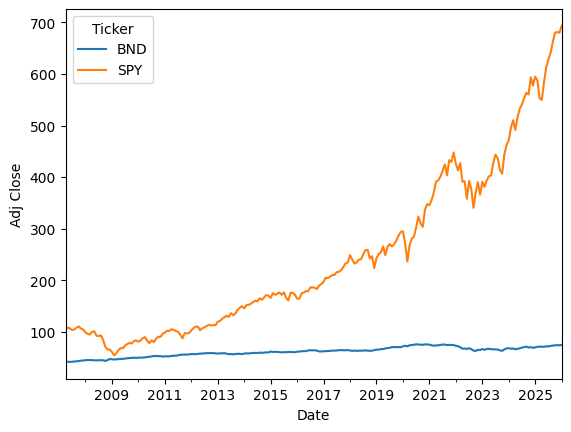

In [46]:
rets.plot(ylabel='Adj Close')

In [47]:
rets = rets.pct_change().dropna() # Return Series

<Axes: xlabel='Date'>

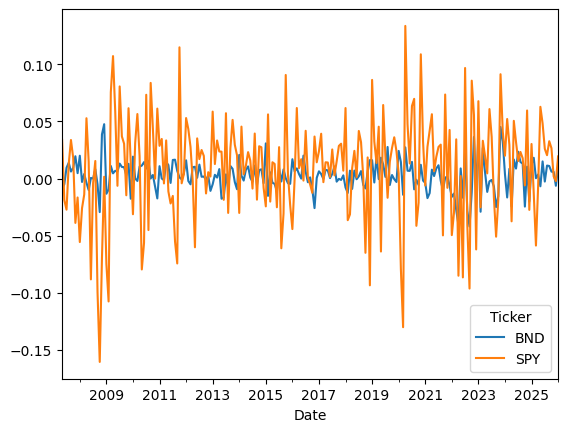

In [48]:
rets.plot()

In [49]:
compound_returns = (rets + 1).prod() - 1
(compound_returns * 100).round(2).astype('str') + '%'

,0
Ticker,
BND,76.75%
SPY,562.21%


In [50]:
rets.head()
rets.tail()
rets.size
rets.shape

(225, 2)

In [51]:
rets.index
rets.columns
rets['SPY']
rets[['SPY']]

Ticker,SPY
Date,
2007-05,0.033920
2007-06,-0.018849
2007-07,-0.027136
2007-08,0.012833
2007-09,0.033810
...,...
2025-09,0.032757
2025-10,0.026676
2025-11,0.001950


In [52]:
rets.loc['2009-02']
rets.iloc[20]

,2009-01
Ticker,
BND,-0.013228
SPY,-0.074663


In [53]:
rets.loc['2009-02': '2009-05']
rets.iloc[20:24]

Ticker,BND,SPY
Date,,
2009-01,-0.013228,-0.074663
2009-02,-0.009570,-0.107449
2009-03,0.011091,0.075613
2009-04,0.004644,0.107214


In [54]:
rets.std() # Standard Deviation

,0
Ticker,
BND,0.013453
SPY,0.045249


In [55]:
n_periods = rets.shape[0]
compounded_growth = (1+rets).prod()
monthly_ret = compounded_growth**(1/n_periods) - 1
(monthly_ret + 1)**12 - 1

,0
Ticker,
BND,0.030841
SPY,0.106079


In [56]:
def annualize_rets(r, periods_per_year=12):
    compounded_growth = (1+r).prod()
    n_periods = r.shape[0]
    return compounded_growth**(periods_per_year / n_periods) - 1

In [57]:
annualize_rets(rets)

,0
Ticker,
BND,0.030841
SPY,0.106079


In [58]:
def annualize_vol(r, periods_per_year=12):
    return r.std() * (periods_per_year**0.5)

In [59]:
annualize_vol(rets)

,0
Ticker,
BND,0.046602
SPY,0.156748


In [60]:
# Raw Sharpe Ratio
annualize_rets(rets) / annualize_vol(rets)

,0
Ticker,
BND,0.661805
SPY,0.676751


<Axes: xlabel='Date'>

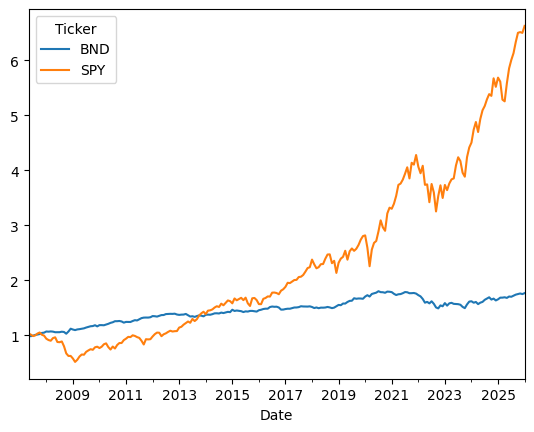

In [61]:
# Growth of 1 dollar
wealth_index = (1+rets).cumprod()
wealth_index.plot()

In [77]:
import yfinance as yf

# Download SPY data without auto-adjust
spy_data_raw = yf.download(tickers='SPY', interval='1mo',start='2001-1-1', auto_adjust=False)

# Extract the 'Adj Close' column, which is part of a MultiIndex for a single ticker
# Then calculate percentage change and drop NaNs
rets = spy_data_raw[('Adj Close', 'SPY')].pct_change().dropna()
rets

[*********************100%***********************]  1 of 1 completed


,Adj Close
,SPY
Date,
2001-02-01,-0.095388
2001-03-01,-0.058572
2001-04-01,0.088363
2001-05-01,-0.005606
2001-06-01,-0.026597
...,...
2025-09-01,0.032757
2025-10-01,0.026676


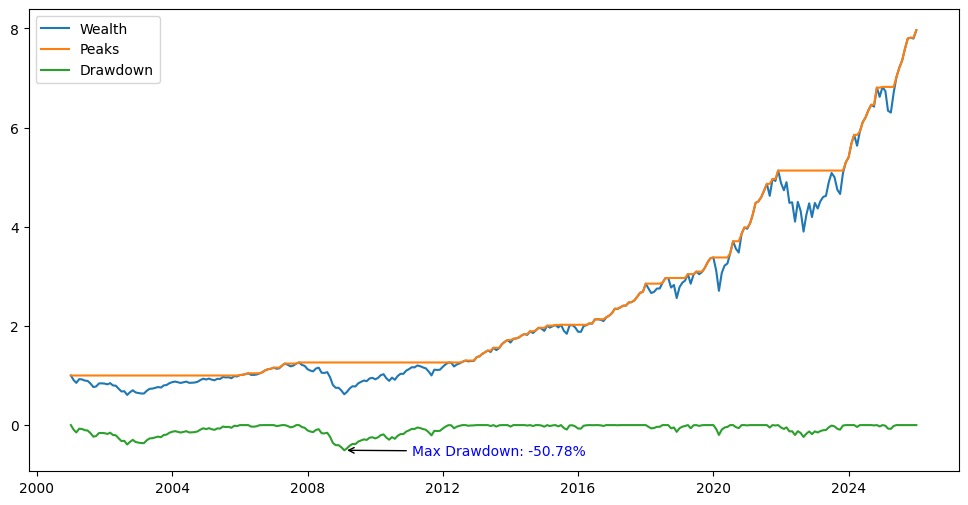

In [78]:
# If rets is a DataFrame, choose a column (or replace with your portfolio returns)
if isinstance(rets, pd.DataFrame):
    col = rets.columns[0]  # <-- change to the column you want
    r = rets[col].dropna()
else:
    r = rets.dropna()

wealth_index = (1 + r).cumprod()

start_date = wealth_index.index.min() - pd.DateOffset(months=1)
wealth_index = pd.concat([pd.Series(1.0, index=[start_date]), wealth_index]).sort_index()

previous_peaks = wealth_index.cummax()
drawdowns = (wealth_index - previous_peaks) / previous_peaks

max_drawdown = drawdowns.min()          # scalar now
max_drawdown_date = drawdowns.idxmin()  # Timestamp now

plt.figure(figsize=(12, 6))
plt.plot(wealth_index, label="Wealth")
plt.plot(previous_peaks, label="Peaks")
plt.plot(drawdowns, label="Drawdown")

plt.annotate(
    f"Max Drawdown: {max_drawdown:.2%}",
    xy=(max_drawdown_date, max_drawdown),
    xytext=(max_drawdown_date + pd.DateOffset(years=2), max_drawdown * 1.2),
    arrowprops=dict(arrowstyle="->", lw=1),
    color="blue"
)
plt.legend()
plt.show()
